# **1. Configuración**

## Imports


In [1]:
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

## Semillas


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

## Device


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu"); print(DEVICE)

cuda


## Dataset


In [4]:
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
BATCH_SIZE = 32

## Modelo


In [5]:
LATENT_DIM = 15

N_QUBITS = 2
N_QNN_LAYERS = 8
SU4_PARAMS = 15

EPOCHS = 50

CNN_LR = 1e-4
QNN_LR = 5e-2

WEIGHT_DECAY = 1e-5

## Etiquetas


In [6]:
LABEL_NEG, LABEL_POS = -1, 1
CLASS_NAMES = {LABEL_NEG: "Normal", LABEL_POS: "Pneumonia"}

## Resumen

In [7]:
print("=" * 70); print("CNN → z15 → SU(4)-QNN fixed 2-qubit circuit"); print("Loss principal: (<Z0 Z1> - y)^2"); print("=" * 70); print(f"Device: {DEVICE}\nSplit: {TRAIN_RATIO:.2f}/{VAL_RATIO:.2f}/{TEST_RATIO:.2f}\nBatch size: {BATCH_SIZE}\nLatent dim: {LATENT_DIM}\nQubits: {N_QUBITS}\nQNN layers: {N_QNN_LAYERS}\nSU(4) params per layer: {SU4_PARAMS}\nEpochs: {EPOCHS}\nCNN LR: {CNN_LR}\nQNN LR: {QNN_LR}"); print("=" * 70)

CNN → z15 → SU(4)-QNN fixed 2-qubit circuit
Loss principal: (<Z0 Z1> - y)^2
Device: cuda
Split: 0.70/0.15/0.15
Batch size: 32
Latent dim: 15
Qubits: 2
QNN layers: 8
SU(4) params per layer: 15
Epochs: 50
CNN LR: 0.0001
QNN LR: 0.05


# **2. Carga y nuevo split 70/15/15**


## Ruta del dataset


In [8]:
DATA_PATH = r"C:\Users\lapic\datasets\medmnist\pneumoniamnist.npz"

## Carga original


In [9]:
data = np.load(DATA_PATH)
X_train_raw, X_val_raw, X_test_raw = data["train_images"], data["val_images"], data["test_images"]
y_train_raw, y_val_raw, y_test_raw = data["train_labels"].squeeze(), data["val_labels"].squeeze(), data["test_labels"].squeeze()

## Unir train + val + test originales


In [10]:
X_all_raw = np.concatenate([X_train_raw, X_val_raw, X_test_raw], axis=0)
y_all_raw = np.concatenate([y_train_raw, y_val_raw, y_test_raw], axis=0)

## Convertir etiquetas a {-1, +1}


In [11]:
y_all = np.where(y_all_raw == 1, LABEL_POS, LABEL_NEG).astype(np.float32)

## Nuevo split estratificado 70/15/15


In [12]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(X_all_raw, y_all, train_size=TRAIN_RATIO, random_state=SEED, stratify=y_all, shuffle=True)
relative_val_ratio = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp_raw, y_temp, train_size=relative_val_ratio, random_state=SEED, stratify=y_temp, shuffle=True)

## Distribuciones


In [13]:
def print_split_distribution(name, X, y):
    values, counts = np.unique(y, return_counts=True)
    print(f"\n{name}\nX: {X.shape}\ny: {y.shape}")
    for value, count in zip(values, counts):
        percentage = 100 * count / len(y)
        print(f"{CLASS_NAMES[int(value)]} ({int(value)}): {count} ({percentage:.2f}%)")

print("=" * 70); print("Dataset original unido"); print("=" * 70); print(f"X_all_raw: {X_all_raw.shape}\ny_all: {y_all.shape}\nPixel range: {X_all_raw.min()} {X_all_raw.max()}")
print_split_distribution("Nuevo TRAIN", X_train_raw, y_train); print_split_distribution("Nuevo VAL", X_val_raw, y_val); print_split_distribution("Nuevo TEST", X_test_raw, y_test)

Dataset original unido
X_all_raw: (5856, 28, 28)
y_all: (5856,)
Pixel range: 0 255

Nuevo TRAIN
X: (4099, 28, 28)
y: (4099,)
Normal (-1): 1108 (27.03%)
Pneumonia (1): 2991 (72.97%)

Nuevo VAL
X: (878, 28, 28)
y: (878,)
Normal (-1): 237 (26.99%)
Pneumonia (1): 641 (73.01%)

Nuevo TEST
X: (879, 28, 28)
y: (879,)
Normal (-1): 238 (27.08%)
Pneumonia (1): 641 (72.92%)


## Resumen en tabla


In [14]:
split_df = pd.DataFrame({"Split": ["Train", "Validation", "Test"], "Samples": [len(y_train), len(y_val), len(y_test)], "Normal (-1)": [np.sum(y_train == LABEL_NEG), np.sum(y_val == LABEL_NEG), np.sum(y_test == LABEL_NEG)], "Pneumonia (+1)": [np.sum(y_train == LABEL_POS), np.sum(y_val == LABEL_POS), np.sum(y_test == LABEL_POS)]})
display(split_df)

,Split,Samples,Normal (-1),Pneumonia (+1)
0,Train,4099,1108,2991
1,Validation,878,237,641
2,Test,879,238,641


## Visualización rápida del nuevo train


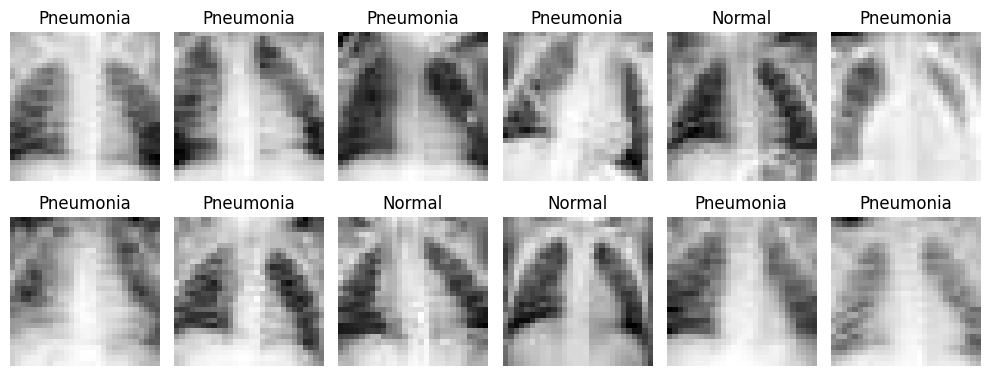

In [15]:
N_SHOW = 12
plt.figure(figsize=(10, 4))
for i in range(N_SHOW):
    plt.subplot(2, 6, i + 1); plt.imshow(X_train_raw[i], cmap="gray"); plt.title(CLASS_NAMES[int(y_train[i])]); plt.axis("off")
plt.tight_layout(); plt.show()

# **3. Preprocesamiento**


## Conversión a float32


In [16]:
X_train = X_train_raw.astype(np.float32)
X_val   = X_val_raw.astype(np.float32)
X_test  = X_test_raw.astype(np.float32)

## Escalamiento [0,1]


In [17]:
X_train /= 255.0; X_val /= 255.0; X_test /= 255.0

## Estadísticas SOLO del train


In [18]:
train_mean = X_train.mean(); train_std = X_train.std(); print(f"Train mean: {train_mean}\nTrain std : {train_std}")

Train mean: 0.5721642971038818
Train std : 0.16829563677310944


## Normalización: $x_{norm} = (x - μ_{train}) / σ_{train}$

In [19]:
X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

## Canal CNN


In [20]:
X_train = np.expand_dims(X_train, axis=1)
X_val = np.expand_dims(X_val, axis=1)
X_test = np.expand_dims(X_test, axis=1)

## Tensores


In [21]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

## Resumen


In [22]:
print("=" * 70); print(f"X_train_t: {X_train_t.shape}\nX_val_t: {X_val_t.shape}\nX_test_t: {X_test_t.shape}\n\ny_train_t: {y_train_t.shape}\ny_val_t: {y_val_t.shape}\ny_test_t: {y_test_t.shape}\n\nTrain mean: {train_mean}\nTrain std: {train_std}"); print("=" * 70)

X_train_t: torch.Size([4099, 1, 28, 28])
X_val_t: torch.Size([878, 1, 28, 28])
X_test_t: torch.Size([879, 1, 28, 28])

y_train_t: torch.Size([4099])
y_val_t: torch.Size([878])
y_test_t: torch.Size([879])

Train mean: 0.5721642971038818
Train std: 0.16829563677310944


# **4. DataLoaders**


## Dataset


In [23]:
class TensorImageDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TensorImageDataset(X_train_t, y_train_t)
val_dataset = TensorImageDataset(X_val_t, y_val_t)
test_dataset = TensorImageDataset(X_test_t, y_test_t)

## DataLoaders


In [24]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

## Sanity batch


In [25]:
xb, yb = next(iter(train_loader))
print("=" * 70); print("DataLoaders"); print("=" * 70)
print(f"Train batches: {len(train_loader)}\nVal batches: {len(val_loader)}\nTest batches: {len(test_loader)}\n\nxb: {xb.shape} {xb.dtype}\nyb: {yb.shape} {yb.dtype}\n\ny min/max: {yb.min().item()} {yb.max().item()}\nx min/max: {xb.min().item()} {xb.max().item()}")
print("=" * 70)

DataLoaders
Train batches: 129
Val batches: 28
Test batches: 28

xb: torch.Size([32, 1, 28, 28]) torch.float32
yb: torch.Size([32]) torch.float32

y min/max: -1.0 1.0
x min/max: -3.399757146835327 2.1693408489227295


# **5. CNN extractor z3**


## Arquitectura


In [26]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.to_z = nn.Linear(16, latent_dim)
    def forward(self, x):
        h = self.features(x)
        h = self.pool(h)
        h = torch.flatten(h, 1)
        z = self.to_z(h)
        return z

## Sanity forward


In [27]:
cnn_test = CNNFeatureExtractor().to(DEVICE)
xb, yb = next(iter(train_loader)); xb = xb.to(DEVICE)
with torch.no_grad(): z_test = cnn_test(xb)
print("=" * 70); print("CNN extractor z15"); print("=" * 70); print(f"Input: {xb.shape}\nz: {z_test.shape}\nz min: {z_test.min().item()}\nz max: {z_test.max().item()}"); print("=" * 70)

CNN extractor z15
Input: torch.Size([32, 1, 28, 28])
z: torch.Size([32, 15])
z min: -0.331520140171051
z max: 0.41318774223327637


# **6. SU(4)-QNN batched**


## Quantum device

In [28]:
qdev = qml.device("default.qubit.torch", wires=N_QUBITS, torch_device=str(DEVICE))
QDEVICE_NAME = "default.qubit.torch"
print("=" * 70); print("Quantum device"); print("=" * 70); print(f"Backend: {QDEVICE_NAME}\nWires: {N_QUBITS}\nInterface: torch\nDiff method: backprop"); print("=" * 70)

Quantum device
Backend: default.qubit.torch
Wires: 2
Interface: torch
Diff method: backprop


## SU(4) data encoding z15

In [29]:
def su4_data_encoding(z):
    qml.Rot(z[:, 0],  z[:, 1],  z[:, 2],  wires=0)       # Encode z0-z2   en Qubit 0
    qml.Rot(z[:, 3],  z[:, 4],  z[:, 5],  wires=1)       # Encode z3-z5   en Qubit 1
    qml.IsingXX(z[:, 6], wires=[0, 1])                   # Encode z6      en XX interaction
    qml.IsingYY(z[:, 7], wires=[0, 1])                   # Encode z7      en YY interaction
    qml.IsingZZ(z[:, 8], wires=[0, 1])                   # Encode z8      en ZZ interaction
    qml.Rot(z[:, 9],  z[:,10], z[:,11], wires=0)         # Encode z9-z11  en Qubit 0
    qml.Rot(z[:,12], z[:,13], z[:,14], wires=1)          # Encode z12-z14 en Qubit 1

## SU(4) variational block

In [30]:
def su4_variational_block(theta_layer):
    qml.Rot(theta_layer[0], theta_layer[1], theta_layer[2], wires=0)          # Rot qubit 0
    qml.Rot(theta_layer[3], theta_layer[4], theta_layer[5], wires=1)          # Rot qubit 1
    qml.IsingXX(theta_layer[6], wires=[0, 1])                                # IsingXX
    qml.IsingYY(theta_layer[7], wires=[0, 1])                                # IsingYY
    qml.IsingZZ(theta_layer[8], wires=[0, 1])                                # IsingZZ
    qml.Rot(theta_layer[9], theta_layer[10], theta_layer[11], wires=0)       # Rot qubit 0
    qml.Rot(theta_layer[12], theta_layer[13], theta_layer[14], wires=1)      # Rot qubit 1

## Batched SU(4) QNode

In [31]:
@qml.qnode(qdev, interface="torch", diff_method="backprop")
def su4_qnode(z, theta):
    for layer in range(N_QNN_LAYERS):
        su4_data_encoding(z)
        su4_variational_block(theta[layer])
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

## Módulo SU(4)-QNN


In [32]:
class SU4QNNLayer(nn.Module):
    def __init__(self):
        super().__init__()
        theta_init = 0.01 * torch.randn(N_QNN_LAYERS, SU4_PARAMS, dtype=torch.float32)
        self.theta = nn.Parameter(theta_init)
    def forward(self, z):
        z_angles = torch.pi * torch.tanh(z)
        return su4_qnode(z_angles, self.theta)

## Sanity check


In [33]:
qnn_test = SU4QNNLayer().to(DEVICE); cnn_test = CNNFeatureExtractor().to(DEVICE)
xb, yb = next(iter(train_loader)); xb = xb.to(DEVICE); yb = yb.to(DEVICE)
with torch.no_grad(): z_test = cnn_test(xb); q_test = qnn_test(z_test)
print("=" * 70); print("Sanity check: CNN → z15 → SU(4)-QNN"); print("=" * 70)
print(f"x shape: {xb.shape}\nz shape: {z_test.shape}\nq output shape: {q_test.shape}\nq output min: {q_test.min().item():.6f}\nq output max: {q_test.max().item():.6f}\nq output dtype: {q_test.dtype}\ntheta shape: {qnn_test.theta.shape}\ntheta device: {qnn_test.theta.device}")
print("=" * 70)
del qnn_test, cnn_test, xb, yb, z_test, q_test; torch.cuda.empty_cache()

Sanity check: CNN → z15 → SU(4)-QNN
x shape: torch.Size([32, 1, 28, 28])
z shape: torch.Size([32, 15])
q output shape: torch.Size([32])
q output min: 0.281893
q output max: 0.964314
q output dtype: torch.float64
theta shape: torch.Size([8, 15])
theta device: cuda:0


# **7. Modelo CNN → DR-QNN**


## Modelo completo


In [34]:
class CNN_SU4_QNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNNFeatureExtractor(latent_dim=LATENT_DIM)
        self.qnn = SU4QNNLayer()

    def forward(self, x, return_z=False):
        z = self.cnn(x)
        q = self.qnn(z)
        return (q, z) if return_z else q

## Sanity check


In [35]:
model_test = CNN_SU4_QNN().to(DEVICE)
xb, yb = next(iter(train_loader)); xb = xb.to(DEVICE); yb = yb.to(DEVICE)
with torch.no_grad(): q_test, z_test = model_test(xb, return_z=True)
print("=" * 70); print("Sanity check: CNN → z15 → SU(4)-QNN"); print("=" * 70)
print(f"x shape: {xb.shape}\nz shape: {z_test.shape}\nq output shape: {q_test.shape}\nq output min: {q_test.min().item():.6f}\nq output max: {q_test.max().item():.6f}\nlabels shape: {yb.shape}\nlabels min/max: {yb.min().item()} / {yb.max().item()}")
print("=" * 70)
del model_test, xb, yb, z_test, q_test; torch.cuda.empty_cache()

Sanity check: CNN → z15 → SU(4)-QNN
x shape: torch.Size([32, 1, 28, 28])
z shape: torch.Size([32, 15])
q output shape: torch.Size([32])
q output min: -0.839256
q output max: 0.043023
labels shape: torch.Size([32])
labels min/max: -1.0 / 1.0


## Conteo de parámetros

In [36]:
model_param_test = CNN_SU4_QNN().to(DEVICE)
cnn_params = sum(p.numel() for p in model_param_test.cnn.parameters() if p.requires_grad)
qnn_params = sum(p.numel() for p in model_param_test.qnn.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_param_test.parameters() if p.requires_grad)
print("=" * 70); print("Trainable parameters"); print("=" * 70)
print(f"CNN parameters: {cnn_params:,}\nQNN parameters: {qnn_params:,}\nTotal parameters: {total_params:,}")
print("=" * 70)
del model_param_test; torch.cuda.empty_cache()

Trainable parameters
CNN parameters: 1,503
QNN parameters: 120
Total parameters: 1,623


# **8. Loss, métricas y evaluación**


## Loss cuántica


In [37]:
def qnn_mse_loss(q_outputs, y):
    return torch.mean((q_outputs.float() - y.float()) ** 2)

## Conversión de salida


In [38]:
def quantum_scores_to_labels(scores):
    return np.where(scores >= 0.0, LABEL_POS, LABEL_NEG)

## Métricas


In [39]:
def compute_binary_metrics(y_true, scores):
    y_true, scores = np.asarray(y_true), np.asarray(scores)
    y_pred = quantum_scores_to_labels(scores)
    y_true_binary = (y_true == LABEL_POS).astype(int)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "bacc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, pos_label=LABEL_POS),
        "auc": roc_auc_score(y_true_binary, scores),
        "prauc": average_precision_score(y_true_binary, scores),
    }

## Evaluación


In [40]:
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    all_y, all_scores, losses = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE).float()
        q_outputs = model(xb)
        losses.append(qnn_mse_loss(q_outputs, yb).item())
        all_y.append(yb.detach().cpu().numpy())
        all_scores.append(q_outputs.detach().cpu().numpy())
    y_true, scores = np.concatenate(all_y), np.concatenate(all_scores)
    metrics = compute_binary_metrics(y_true, scores)
    metrics["loss"] = float(np.mean(losses))
    return metrics, y_true, scores

## Sanity evaluation


In [41]:
model_eval_test = CNN_SU4_QNN().to(DEVICE)
train_metrics_test, y_train_test, scores_train_test = evaluate_model(model_eval_test, train_loader)
print("=" * 70); print("Sanity check: evaluation"); print("=" * 70)
print(f"loss: {train_metrics_test['loss']:.6f}\nacc: {train_metrics_test['acc']:.4f}\nbacc: {train_metrics_test['bacc']:.4f}\nf1: {train_metrics_test['f1']:.4f}\nauc: {train_metrics_test['auc']:.4f}\nprauc: {train_metrics_test['prauc']:.4f}")
print("-" * 70); print(f"y shape: {y_train_test.shape}\nscores shape: {scores_train_test.shape}\nscores min: {scores_train_test.min():.6f}\nscores max: {scores_train_test.max():.6f}")
print("=" * 70)
del model_eval_test, y_train_test, scores_train_test; torch.cuda.empty_cache()

Sanity check: evaluation
loss: 0.910805
acc: 0.6606
bacc: 0.6104
f1: 0.7558
auc: 0.6692
prauc: 0.8335
----------------------------------------------------------------------
y shape: (4099,)
scores shape: (4099,)
scores min: -0.990611
scores max: 0.897535


# 9. Entrenamiento CNN → z15 → SU(4)-QNN


## Inicialización del modelo


In [42]:
model = CNN_SU4_QNN().to(DEVICE)
optimizer = optim.Adam([{"params": model.cnn.parameters(), "lr": CNN_LR, "weight_decay": WEIGHT_DECAY}, {"params": model.qnn.parameters(), "lr": QNN_LR, "weight_decay": 0.0}])
history, best_val_bacc, best_state, best_epoch = [], -np.inf, None, None
print("=" * 70); print("Training setup"); print("=" * 70); print(model); print("=" * 70)

Training setup
CNN_SU4_QNN(
  (cnn): CNNFeatureExtractor(
    (features): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (pool): AdaptiveAvgPool2d(output_size=(1, 1))
    (to_z): Linear(in_features=16, out_features=15, bias=True)
  )
  (qnn): SU4QNNLayer()
)


## Train epoch


In [43]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    all_y, all_scores, losses = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE).float()
        optimizer.zero_grad()
        q_outputs = model(xb)
        loss = qnn_mse_loss(q_outputs, yb)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
        all_y.append(yb.detach().cpu().numpy())
        all_scores.append(q_outputs.detach().cpu().numpy())
    y_true, scores = np.concatenate(all_y), np.concatenate(all_scores)
    metrics = compute_binary_metrics(y_true, scores)
    metrics["loss"] = float(np.mean(losses))
    return metrics

## Entrenamiento


In [44]:
import copy, time
print("=" * 70); print("Training CNN → z15 → SU(4)-QNN"); print("=" * 70)
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_metrics = train_one_epoch(model, train_loader, optimizer)
    val_metrics, _, _ = evaluate_model(model, val_loader)
    dt = time.time() - t0
    row = {"epoch": epoch, "time_s": dt, "train_loss": train_metrics["loss"], "train_acc": train_metrics["acc"], "train_bacc": train_metrics["bacc"], "train_f1": train_metrics["f1"], "train_auc": train_metrics["auc"], "train_prauc": train_metrics["prauc"], "val_loss": val_metrics["loss"], "val_acc": val_metrics["acc"], "val_bacc": val_metrics["bacc"], "val_f1": val_metrics["f1"], "val_auc": val_metrics["auc"], "val_prauc": val_metrics["prauc"]}
    history.append(row)
    if val_metrics["bacc"] > best_val_bacc:
        best_val_bacc, best_epoch, best_state = val_metrics["bacc"], epoch, copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch:02d}/{EPOCHS} | dt={dt:.1f}s | train_loss={train_metrics['loss']:.4f} | train_acc={train_metrics['acc']:.4f} | val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | val_bacc={val_metrics['bacc']:.4f} | val_f1={val_metrics['f1']:.4f} | val_auc={val_metrics['auc']:.4f}")
print("=" * 70); print(f"Best epoch: {best_epoch}\nBest val bAcc: {best_val_bacc:.4f}"); print("=" * 70)

Training CNN → z15 → SU(4)-QNN
Epoch 01/50 | dt=49.9s | train_loss=0.5685 | train_acc=0.8026 | val_loss=0.5939 | val_acc=0.8098 | val_bacc=0.6583 | val_f1=0.8835 | val_auc=0.7739
Epoch 02/50 | dt=49.8s | train_loss=0.4572 | train_acc=0.8483 | val_loss=0.4697 | val_acc=0.8576 | val_bacc=0.8014 | val_f1=0.9045 | val_auc=0.8917
Epoch 03/50 | dt=48.0s | train_loss=0.4382 | train_acc=0.8500 | val_loss=0.4305 | val_acc=0.8645 | val_bacc=0.7862 | val_f1=0.9115 | val_auc=0.9150
Epoch 04/50 | dt=49.8s | train_loss=0.4143 | train_acc=0.8651 | val_loss=0.3846 | val_acc=0.8759 | val_bacc=0.8418 | val_f1=0.9150 | val_auc=0.9312
Epoch 05/50 | dt=49.3s | train_loss=0.3906 | train_acc=0.8685 | val_loss=0.5095 | val_acc=0.8337 | val_bacc=0.8569 | val_f1=0.8763 | val_auc=0.9361
Epoch 06/50 | dt=49.4s | train_loss=0.3816 | train_acc=0.8761 | val_loss=0.5507 | val_acc=0.8052 | val_bacc=0.8480 | val_f1=0.8499 | val_auc=0.9391
Epoch 07/50 | dt=49.6s | train_loss=0.3725 | train_acc=0.8714 | val_loss=0.3350 |

## Restaurar mejor modelo y evaluar en test

In [45]:
model.load_state_dict(best_state)
train_metrics_final, y_train_final, scores_train_final = evaluate_model(model, train_loader)
val_metrics_final, y_val_final, scores_val_final = evaluate_model(model, val_loader)
test_metrics_final, y_test_final, scores_test_final = evaluate_model(model, test_loader)
print("=" * 70); print("Final evaluation with best validation checkpoint"); print("=" * 70)
print(f"Best epoch: {best_epoch}")
print("-" * 70)
print(f"TRAIN | loss={train_metrics_final['loss']:.4f} | acc={train_metrics_final['acc']:.4f} | bacc={train_metrics_final['bacc']:.4f} | f1={train_metrics_final['f1']:.4f} | auc={train_metrics_final['auc']:.4f} | prauc={train_metrics_final['prauc']:.4f}")
print(f"VAL   | loss={val_metrics_final['loss']:.4f} | acc={val_metrics_final['acc']:.4f} | bacc={val_metrics_final['bacc']:.4f} | f1={val_metrics_final['f1']:.4f} | auc={val_metrics_final['auc']:.4f} | prauc={val_metrics_final['prauc']:.4f}")
print(f"TEST  | loss={test_metrics_final['loss']:.4f} | acc={test_metrics_final['acc']:.4f} | bacc={test_metrics_final['bacc']:.4f} | f1={test_metrics_final['f1']:.4f} | auc={test_metrics_final['auc']:.4f} | prauc={test_metrics_final['prauc']:.4f}")
print("=" * 70)

Final evaluation with best validation checkpoint
Best epoch: 46
----------------------------------------------------------------------
TRAIN | loss=0.1907 | acc=0.9400 | bacc=0.9197 | f1=0.9591 | auc=0.9818 | prauc=0.9932
VAL   | loss=0.1907 | acc=0.9499 | bacc=0.9324 | f1=0.9658 | auc=0.9805 | prauc=0.9924
TEST  | loss=0.2263 | acc=0.9272 | bacc=0.8959 | f1=0.9508 | auc=0.9714 | prauc=0.9888


# **10. Resultados**


## Resumen numérico


In [46]:
history_df = pd.DataFrame(history)
display(history_df)
print("=" * 70); print("Training summary"); print("=" * 70); print(f"Best epoch: {best_epoch}\nBest val bAcc: {best_val_bacc:.4f}"); print("=" * 70)

,epoch,time_s,train_loss,train_acc,train_bacc,train_f1,train_auc,train_prauc,val_loss,val_acc,val_bacc,val_f1,val_auc,val_prauc
0,1,49.912527,0.568517,0.802635,0.711065,0.870663,0.822680,0.914725,0.593923,0.809795,0.658317,0.883461,0.773923,0.866747
1,2,49.766973,0.457232,0.848256,0.778406,0.899483,0.886137,0.945759,0.469722,0.857631,0.801441,0.904507,0.891704,0.948332
2,3,48.018140,0.438218,0.849963,0.786963,0.899886,0.901166,0.957551,0.430517,0.864465,0.786176,0.911524,0.915033,0.962919
3,4,49.768391,0.414294,0.865089,0.808691,0.909714,0.909321,0.958974,0.384605,0.875854,0.841845,0.915043,0.931166,0.971592
4,5,49.338691,0.390554,0.868505,0.816713,0.911625,0.923095,0.966395,0.509501,0.833713,0.856863,0.876271,0.936077,0.971844
5,6,49.436741,0.381557,0.876067,0.829282,0.916420,0.931913,0.972039,0.550693,0.805239,0.847999,0.849868,0.939079,0.976010
6,7,49.627585,0.372541,0.871432,0.824685,0.913165,0.927501,0.968296,0.334959,0.881549,0.827129,0.920973,0.944048,0.976935
7,8,49.228611,0.330769,0.894364,0.852615,0.928748,0.945513,0.977736,0.331895,0.895216,0.855105,0.929231,0.944779,0.972538
8,9,49.561742,0.329089,0.895096,0.853401,0.929253,0.948160,0.977844,0.310330,0.899772,0.852907,0.932927,0.956588,0.982489
9,10,49.658122,0.329098,0.894852,0.856074,0.928843,0.946835,0.978351,0.406413,0.858770,0.746375,0.911047,0.939599,0.967825


Training summary
Best epoch: 46
Best val bAcc: 0.9324


## Mejor modelo


In [47]:
model.load_state_dict(best_state); model.eval()
train_metrics, y_train_eval, scores_train_eval = evaluate_model(model, train_loader)
val_metrics, y_val_eval, scores_val_eval = evaluate_model(model, val_loader)
test_metrics, y_test_eval, scores_test_eval = evaluate_model(model, test_loader)
summary_df = pd.DataFrame([{"split": "train", **train_metrics}, {"split": "val", **val_metrics}, {"split": "test", **test_metrics}])
display(summary_df)

,split,acc,bacc,f1,auc,prauc,loss
0,train,0.939985,0.919671,0.959082,0.981825,0.993234,0.193213
1,val,0.949886,0.932437,0.965839,0.980503,0.992355,0.190733
2,test,0.927190,0.895925,0.950769,0.971355,0.988768,0.226274


## Curvas de entrenamiento


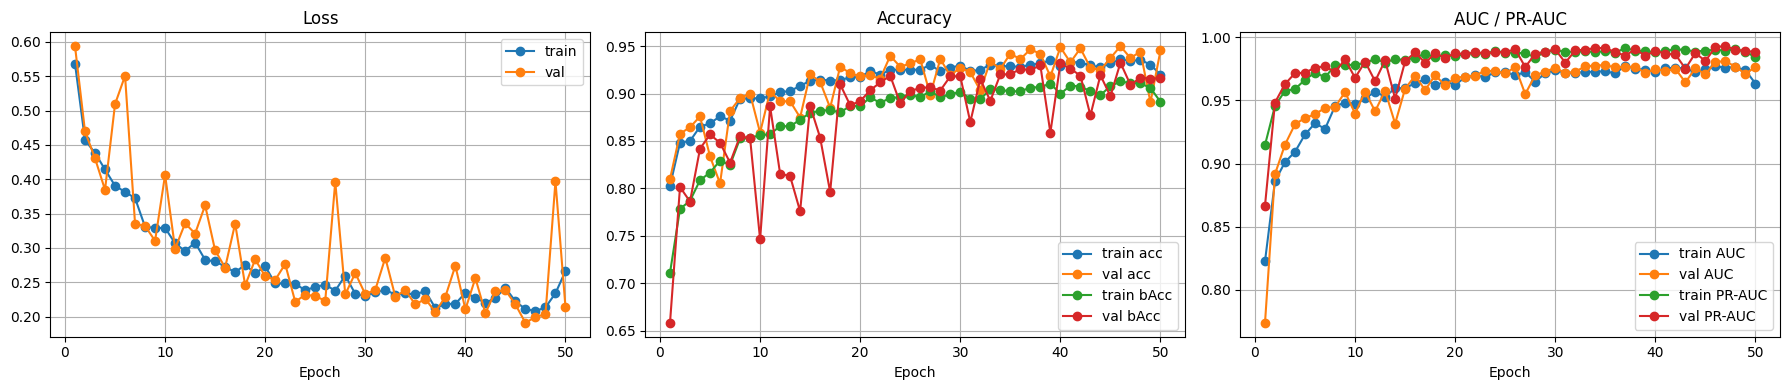

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train"); axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(True); axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train acc"); axes[1].plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val acc")
axes[1].plot(history_df["epoch"], history_df["train_bacc"], marker="o", label="train bAcc"); axes[1].plot(history_df["epoch"], history_df["val_bacc"], marker="o", label="val bAcc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].grid(True); axes[1].legend()
axes[2].plot(history_df["epoch"], history_df["train_auc"], marker="o", label="train AUC"); axes[2].plot(history_df["epoch"], history_df["val_auc"], marker="o", label="val AUC")
axes[2].plot(history_df["epoch"], history_df["train_prauc"], marker="o", label="train PR-AUC"); axes[2].plot(history_df["epoch"], history_df["val_prauc"], marker="o", label="val PR-AUC")
axes[2].set_title("AUC / PR-AUC"); axes[2].set_xlabel("Epoch"); axes[2].grid(True); axes[2].legend()
plt.tight_layout(); plt.show()

## Diagnóstico del test


Test diagnosis
Test loss: 0.2263
Test acc: 0.9272
Test bAcc: 0.8959
Test F1: 0.9508
Test AUC: 0.9714
Test PR-AUC: 0.9888


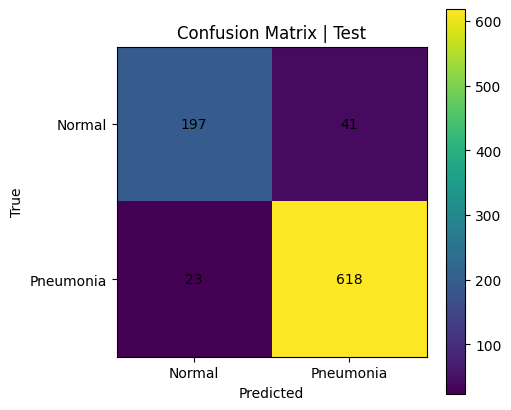

[[197  41]
 [ 23 618]]


In [49]:
y_test_pred = quantum_scores_to_labels(scores_test_eval)
cm = confusion_matrix(y_test_eval, y_test_pred, labels=[LABEL_NEG, LABEL_POS])
print("=" * 70); print("Test diagnosis"); print("=" * 70)
print(f"Test loss: {test_metrics['loss']:.4f}\nTest acc: {test_metrics['acc']:.4f}\nTest bAcc: {test_metrics['bacc']:.4f}\nTest F1: {test_metrics['f1']:.4f}\nTest AUC: {test_metrics['auc']:.4f}\nTest PR-AUC: {test_metrics['prauc']:.4f}")
print("=" * 70)
plt.figure(figsize=(5, 5)); plt.imshow(cm); plt.title("Confusion Matrix | Test")
plt.xticks([0, 1], [CLASS_NAMES[LABEL_NEG], CLASS_NAMES[LABEL_POS]])
plt.yticks([0, 1], [CLASS_NAMES[LABEL_NEG], CLASS_NAMES[LABEL_POS]])
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar(); plt.show()
print(cm)